In [1]:
# In this step we import libraries required for MNIST loading, CNN training, and plotting.
# We also import helpers for stratified split and reusable data loading.
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

In [2]:
# In this step we define the global seed function and apply it.
# Same seed is set for python, numpy, and torch for reproducibility.
# So model comparisons become fair across different runs.
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: None (running on CPU)")

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


# Part-A

In [3]:
# This cell loads standard MNIST from the local mnist_data folder.
# Training mean and std are computed first and then used for normalization.
# Test dataset is loaded with the same normalization for final assignment evaluation.
DATA_ROOT = "./mnist_data"

raw_train_dataset = datasets.MNIST(
    root=DATA_ROOT,
    train=True,
    download=False,
)

train_mean = raw_train_dataset.data.float().mean() / 255.0
train_std = raw_train_dataset.data.float().std() / 255.0

mnist_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((train_mean.item(),), (train_std.item(),)),
])

CLASSES = [str(i) for i in range(10)]

full_train_dataset = datasets.MNIST(
    root=DATA_ROOT,
    train=True,
    download=False,
    transform=mnist_tfms,
)

test_dataset = datasets.MNIST(
    root=DATA_ROOT,
    train=False,
    download=False,
    transform=mnist_tfms,
)

print(f"Full train samples: {len(full_train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Train mean: {train_mean:.5f}")
print(f"Train std: {train_std:.5f}")

Full train samples: 60000
Test samples: 10000
Train mean: 0.13066
Train std: 0.30811


In [4]:
# Now we create stratified train-validation split using same class ratio.
# After split, dataloaders are built with chosen batch size.
BATCH_SIZE = 256

all_idx = np.arange(len(full_train_dataset))
all_labels = full_train_dataset.targets.numpy()

train_idx, val_idx = train_test_split(
    all_idx,
    test_size=0.30,
    random_state=SEED,
    stratify=all_labels,
    shuffle=True,
)

train_dataset = Subset(full_train_dataset, train_idx)
val_dataset = Subset(full_train_dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, num_workers=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=2, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=2, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)} | Test samples: {len(test_dataset)}")


Train samples: 42000 | Validation samples: 18000 | Test samples: 10000


In [5]:
# This block defines one-epoch training function.
# It runs forward pass, loss, backward pass, and optimizer update.
# Finally it returns average train loss and train accuracy.
def train_one_epoch(model, data_loader, criterion, optimizer):
    model.train()
    individual_loss_sum = 0
    correct_predicted = 0
    total_data = 0

    for each_inputs, each_targets in data_loader:
        each_inputs = each_inputs.to(DEVICE)
        each_targets = each_targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(each_inputs)
        loss = criterion(outputs, each_targets)
        loss.backward()
        optimizer.step()

        individual_loss_sum = individual_loss_sum + loss.item() * each_inputs.size(0)
        correct_predicted = correct_predicted + (torch.max(outputs, 1)[1] == each_targets).sum().item()
        total_data = total_data + each_targets.size(0)

    epoch_loss = individual_loss_sum / total_data
    epoch_accuracy = correct_predicted / total_data
    return epoch_loss, epoch_accuracy


In [6]:
# Here we define evaluation function with no gradient updates.
# Model is switched to eval mode and metrics are computed batch-wise.
def evaluate(model, data_loader, criterion):
    model.eval()
    individual_loss_sum = 0
    correct_predicted = 0
    total_data = 0

    with torch.no_grad():
        for each_inputs, each_targets in data_loader:
            each_inputs = each_inputs.to(DEVICE)
            each_targets = each_targets.to(DEVICE)

            outputs = model(each_inputs)
            loss = criterion(outputs, each_targets)

            individual_loss_sum = individual_loss_sum + loss.item() * each_inputs.size(0)
            correct_predicted = correct_predicted + (torch.max(outputs, 1)[1] == each_targets).sum().item()
            total_data = total_data + each_targets.size(0)

    epoch_loss = individual_loss_sum / total_data
    epoch_accuracy = correct_predicted / total_data
    return epoch_loss, epoch_accuracy


In [7]:
# This helper counts trainable parameters in any model.
# We use it to verify that Task 1 parameter budget stays within 50,000.
def parameters_count(model):
    total_params = 0
    for p in model.parameters():
        if p.requires_grad:
            total_params = total_params + p.numel()
    return total_params


In [8]:
# This cell defines the Task 1 custom CNN for standard MNIST.
# Architecture uses 2 convolutional layers and 2 linear layers while staying below 50k parameters.
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()

        # feature learning part of cnn
        self.features = nn.Sequential(
            # performing convolution while keeping image size 28 by 28 and changing channels from 1 to 16
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            # applying relu non-linearity after first convolution
            nn.ReLU(),
            # reducing spatial size from 28 by 28 to 14 by 14
            nn.MaxPool2d(2, 2),

            # performing second convolution while keeping image size 14 by 14 and changing channels from 16 to 24
            nn.Conv2d(16, 24, kernel_size=3, padding=1),
            # applying relu again after second convolution
            nn.ReLU(),
            # reducing spatial size from 14 by 14 to 7 by 7
            nn.MaxPool2d(2, 2)
        )

        # classifier ann where final decision for 10 classes is made
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(24 * 7 * 7, 32),
            nn.GELU(),
            nn.Linear(32, 10)
        )

    def forward(self, result):
        result = self.features(result)
        result = self.classifier(result)
        # return final output logits
        return result

cnn_model = MNIST_CNN().to(DEVICE)
cnn_params = parameters_count(cnn_model)
print("MNIST CNN params:", cnn_params)
assert cnn_params <= 50_000, "MNIST CNN exceeds 50,000 params"


MNIST CNN params: 41634


In [9]:
# Now we configure Task 1 loss, optimizer, and lr scheduler.
# Training loop runs for full epochs and tracks train/val metrics.
# Printed logs help monitor learning and generalization gap.
loss_function_cnn = nn.CrossEntropyLoss()
EPOCHS = 15

cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
cnn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    cnn_optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

cnn_train_losses = []
cnn_val_losses = []
cnn_train_accs = []
cnn_val_accs = []

print("||Task 1 Part A: MNIST CNN Training||")

for each_epoch in range(EPOCHS):

    training_loss, training_accuracy = train_one_epoch(cnn_model, train_loader, loss_function_cnn, cnn_optimizer)
    validation_loss, validation_accuracy = evaluate(cnn_model, val_loader, loss_function_cnn)
    cnn_scheduler.step(validation_accuracy)

    cnn_train_losses.append(training_loss)
    cnn_val_losses.append(validation_loss)
    cnn_train_accs.append(training_accuracy)
    cnn_val_accs.append(validation_accuracy)

    current_lr = cnn_optimizer.param_groups[0]["lr"]

    print(f"Epoch [{each_epoch+1}/{EPOCHS}] | LR {current_lr:.6f} | "
        f"Train Loss {training_loss:.5f}, Train Acc {training_accuracy:.5f} | "
        f"Val Loss {validation_loss:.5f}, Val Acc {validation_accuracy:.5f}")


||Task 1 Part A: MNIST CNN Training||
Epoch [1/15] | LR 0.001000 | Train Loss 0.51823, Train Acc 0.83774 | Val Loss 0.19005, Val Acc 0.94222
Epoch [2/15] | LR 0.001000 | Train Loss 0.11845, Train Acc 0.96555 | Val Loss 0.09754, Val Acc 0.97017
Epoch [3/15] | LR 0.001000 | Train Loss 0.07720, Train Acc 0.97700 | Val Loss 0.07886, Val Acc 0.97683
Epoch [4/15] | LR 0.001000 | Train Loss 0.06078, Train Acc 0.98205 | Val Loss 0.06177, Val Acc 0.98089
Epoch [5/15] | LR 0.001000 | Train Loss 0.04971, Train Acc 0.98483 | Val Loss 0.05695, Val Acc 0.98206
Epoch [6/15] | LR 0.001000 | Train Loss 0.04119, Train Acc 0.98740 | Val Loss 0.05342, Val Acc 0.98367
Epoch [7/15] | LR 0.001000 | Train Loss 0.03754, Train Acc 0.98867 | Val Loss 0.05162, Val Acc 0.98461
Epoch [8/15] | LR 0.001000 | Train Loss 0.03033, Train Acc 0.99100 | Val Loss 0.05669, Val Acc 0.98306
Epoch [9/15] | LR 0.001000 | Train Loss 0.02904, Train Acc 0.99140 | Val Loss 0.04947, Val Acc 0.98428
Epoch [10/15] | LR 0.000500 | Train

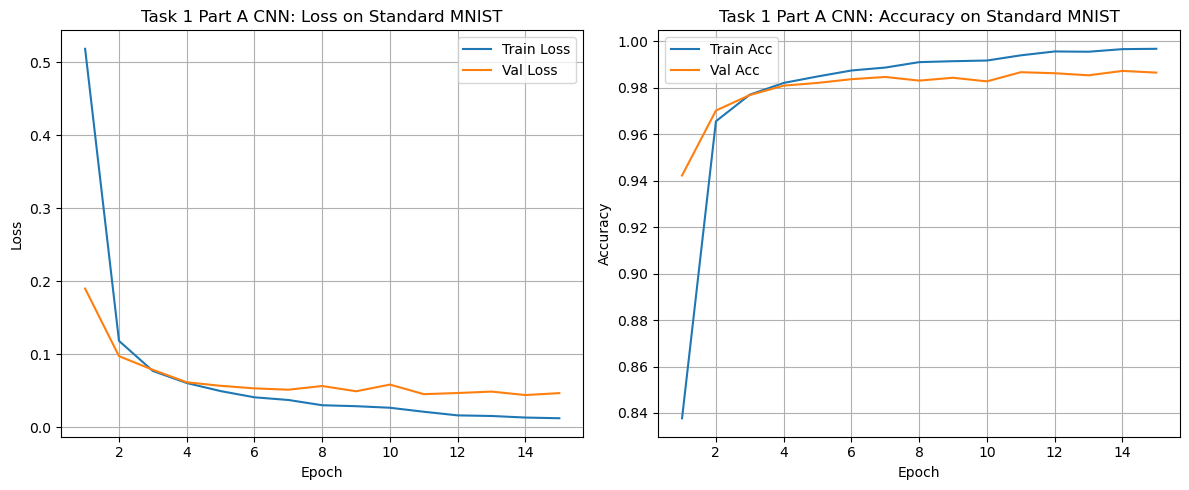

In [10]:
# This block plots Task 1 training and validation curves.
# Both loss and accuracy trends are shown side by side.
epochs_range_cnn = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_cnn, cnn_train_losses, label="Train Loss")
plt.plot(epochs_range_cnn, cnn_val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 1 Part A CNN: Loss on Standard MNIST")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range_cnn, cnn_train_accs, label="Train Acc")
plt.plot(epochs_range_cnn, cnn_val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Task 1 Part A CNN: Accuracy on Standard MNIST")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [11]:
# Here we run final evaluation on train, validation, and test loaders.
# These metrics can be used directly in the assignment report.
cnn_train_loss, cnn_train_acc = evaluate(cnn_model, train_loader, loss_function_cnn)
cnn_val_loss, cnn_val_acc = evaluate(cnn_model, val_loader, loss_function_cnn)
cnn_test_loss, cnn_test_acc = evaluate(cnn_model, test_loader, loss_function_cnn)

print(f"CNN Train Loss: {cnn_train_loss:.5f}")
print(f"CNN Train Acc : {cnn_train_acc:.5f}")
print(f"CNN Val Loss  : {cnn_val_loss:.5f}")
print(f"CNN Val Acc   : {cnn_val_acc:.5f}")
print(f"CNN Test Loss : {cnn_test_loss:.5f}")
print(f"CNN Test Acc  : {cnn_test_acc:.5f}")


CNN Train Loss: 0.00985
CNN Train Acc : 0.99807
CNN Val Loss  : 0.04693
CNN Val Acc   : 0.98650
CNN Test Loss : 0.03660
CNN Test Acc  : 0.98820


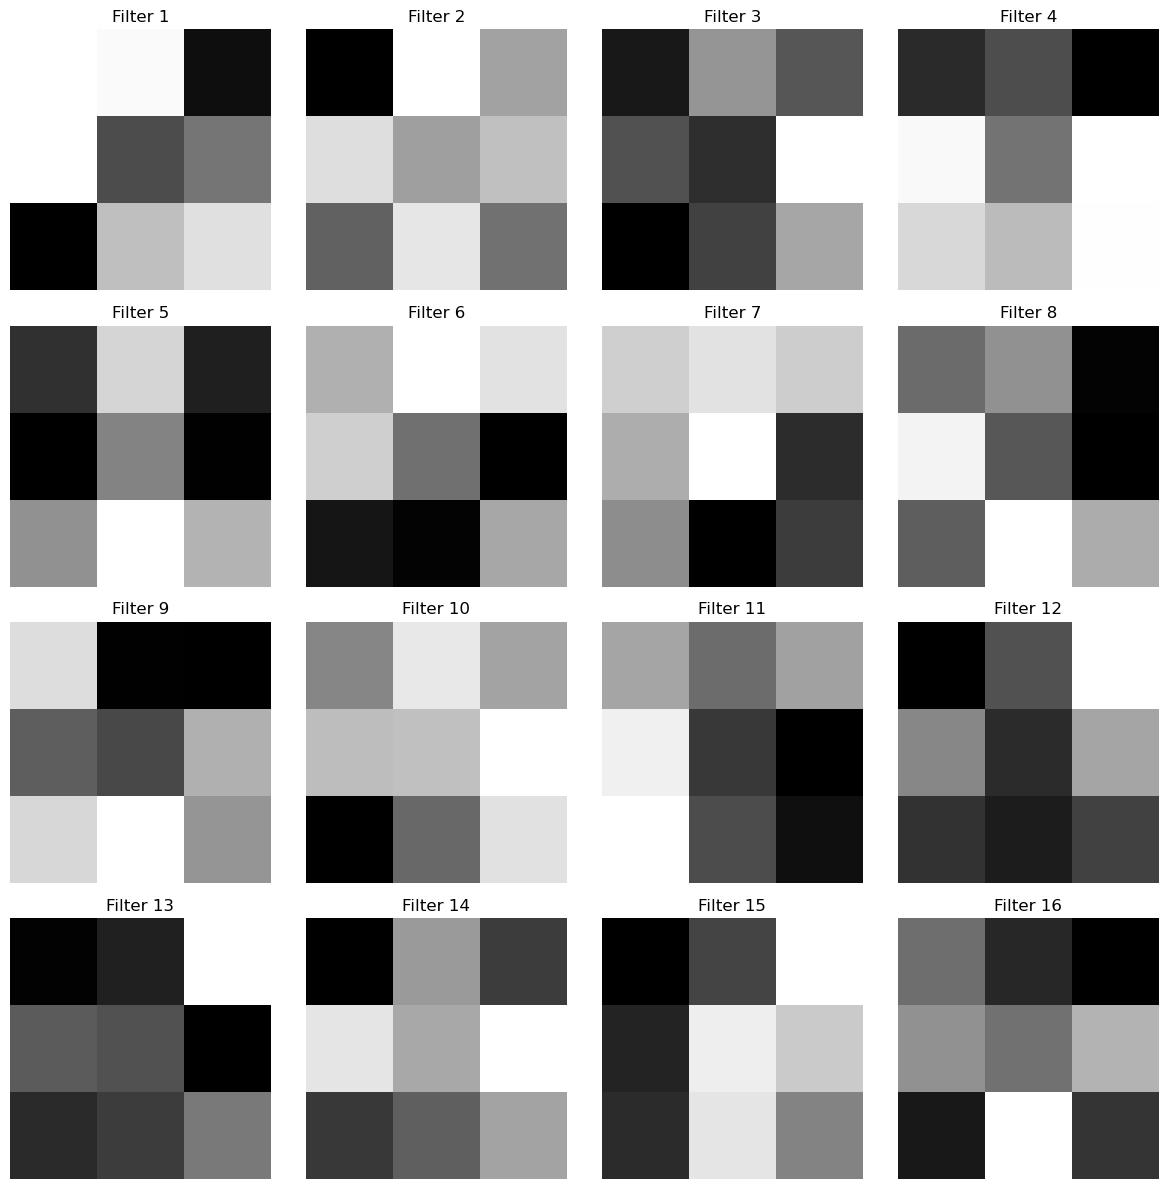

In [12]:
# This cell plots filters learned in the first convolutional layer.
# It helps inspect whether simple edge or stroke detectors have emerged.
first_layer_filters = cnn_model.features[0].weight.detach().cpu()

num_filters = first_layer_filters.size(0)
cols = 4
rows = int(np.ceil(num_filters / cols))

plt.figure(figsize=(3 * cols, 3 * rows))

for k in range(num_filters):
    plt.subplot(rows, cols, k + 1)
    plt.imshow(first_layer_filters[k, 0], cmap="gray")
    plt.title(f"Filter {k+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Part-B

In [13]:
# This cell defines the C-MNIST dataset class and loads all splits.
# Train-set mean and std are computed once and then reused for every split.
# This keeps normalization consistent across biased and unbiased evaluation.
CMNIST_ROOT = "./cmnist"
TRAIN_BIASED_FILE = f"{CMNIST_ROOT}/train_biased.pt"
TEST_BIASED_FILE = f"{CMNIST_ROOT}/test_biased.pt"
TEST_UNBIASED_FILE = f"{CMNIST_ROOT}/test_unbiased.pt"

class CMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, file_path, mean=None, std=None):
        loaded_x, loaded_y = torch.load(file_path, map_location="cpu")
        self.x = loaded_x.float()
        self.y = loaded_y.long()

        if self.x.max().item() > 1:
            self.x = self.x / 255.0

        if mean is None or std is None:
            self.mean = self.x.mean(dim=(0, 2, 3))
            self.std = self.x.std(dim=(0, 2, 3))
        else:
            self.mean = mean
            self.std = std

        self.std = torch.clamp(self.std, min=1e-6)
        self.x = (self.x - self.mean.view(1, 3, 1, 1)) / self.std.view(1, 3, 1, 1)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        label = self.y[idx]
        return img, label

cmnist_full_train_dataset = CMNISTDataset(TRAIN_BIASED_FILE)
cmnist_mean = cmnist_full_train_dataset.mean
cmnist_std = cmnist_full_train_dataset.std

cmnist_test_biased_dataset = CMNISTDataset(TEST_BIASED_FILE, mean=cmnist_mean, std=cmnist_std)
cmnist_test_unbiased_dataset = CMNISTDataset(TEST_UNBIASED_FILE, mean=cmnist_mean, std=cmnist_std)

print(f"Biased train samples: {len(cmnist_full_train_dataset)}")
print(f"Biased test samples: {len(cmnist_test_biased_dataset)}")
print(f"Unbiased test samples: {len(cmnist_test_unbiased_dataset)}")
print(f"Train mean: {[round(v, 5) for v in cmnist_mean.tolist()]}")
print(f"Train std: {[round(v, 5) for v in cmnist_std.tolist()]}")


/tmp/ipykernel_74448/3923194394.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_x, loaded_y = torch.load(file_path, map_location="cpu")


Biased train samples: 60000
Biased test samples: 10000
Unbiased test samples: 10000
Train mean: [0.08362, 0.05458, 0.05548]
Train std: [0.24324, 0.18947, 0.19724]


In [14]:
# Now we create stratified train-validation split for biased training data.
# After split, dataloaders are built for train, validation, biased test, and unbiased test.
CMNIST_BATCH_SIZE = 256

all_idx = np.arange(len(cmnist_full_train_dataset))
all_labels = cmnist_full_train_dataset.y.numpy()

cmnist_train_idx, cmnist_val_idx = train_test_split(
    all_idx,
    test_size=0.30,
    random_state=SEED,
    stratify=all_labels,
    shuffle=True,
)

cmnist_train_dataset = Subset(cmnist_full_train_dataset, cmnist_train_idx)
cmnist_val_dataset = Subset(cmnist_full_train_dataset, cmnist_val_idx)

cmnist_train_loader = DataLoader(cmnist_train_dataset, batch_size=CMNIST_BATCH_SIZE, num_workers=2, shuffle=True)
cmnist_val_loader = DataLoader(cmnist_val_dataset, batch_size=CMNIST_BATCH_SIZE, num_workers=2, shuffle=False)
cmnist_test_biased_loader = DataLoader(cmnist_test_biased_dataset, batch_size=CMNIST_BATCH_SIZE, num_workers=2, shuffle=False)
cmnist_test_unbiased_loader = DataLoader(cmnist_test_unbiased_dataset, batch_size=CMNIST_BATCH_SIZE, num_workers=2, shuffle=False)

print(f"Train samples: {len(cmnist_train_dataset)} | Validation samples: {len(cmnist_val_dataset)}")


Train samples: 42000 | Validation samples: 18000


In [15]:
# This cell defines the Task 1 Part B CNN adapted for RGB Colored-MNIST.
# Architecture uses 2 convolutional layers and 2 linear layers while staying below 50k parameters.
class CMNIST_CNN(nn.Module):
    def __init__(self):
        super(CMNIST_CNN, self).__init__()

        # feature learning part of cnn
        self.features = nn.Sequential(
            # performing convolution while keeping image size same and changing channels from 3 to 16
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            # applying relu non-linearity after first convolution
            nn.ReLU(),
            # reducing spatial size by half
            nn.MaxPool2d(2, 2),

            # performing second convolution while keeping image size same and changing channels from 16 to 24
            nn.Conv2d(16, 24, kernel_size=3, padding=1),
            # applying relu again after second convolution
            nn.ReLU(),
            # reducing spatial size by half again
            nn.MaxPool2d(2, 2)
        )

        # classifier ann where final decision for 10 classes is made
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(24 * 7 * 7, 32),
            nn.GELU(),
            nn.Linear(32, 10)
        )

    def forward(self, result):
        result = self.features(result)
        result = self.classifier(result)
        # return final output logits
        return result

cmnist_model = CMNIST_CNN().to(DEVICE)
cmnist_params = parameters_count(cmnist_model)
print("C-MNIST CNN params:", cmnist_params)
assert cmnist_params <= 50_000, "C-MNIST CNN exceeds 50,000 params"


C-MNIST CNN params: 41922


In [16]:
# Now we configure Part B loss, optimizer, and lr scheduler.
# Training loop runs on biased C-MNIST data and tracks validation metrics.
# Printed logs help reveal whether the model overfits to shortcut color cues.
loss_function_cmnist = nn.CrossEntropyLoss()
EPOCHS_CMNIST = 15

cmnist_optimizer = torch.optim.Adam(cmnist_model.parameters(), lr=1e-3)
cmnist_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    cmnist_optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

cmnist_train_losses = []
cmnist_val_losses = []
cmnist_train_accs = []
cmnist_val_accs = []

print("||Task 1 Part B: C-MNIST CNN Training||")

for each_epoch in range(EPOCHS_CMNIST):

    training_loss, training_accuracy = train_one_epoch(cmnist_model, cmnist_train_loader, loss_function_cmnist, cmnist_optimizer)
    validation_loss, validation_accuracy = evaluate(cmnist_model, cmnist_val_loader, loss_function_cmnist)
    cmnist_scheduler.step(validation_accuracy)

    cmnist_train_losses.append(training_loss)
    cmnist_val_losses.append(validation_loss)
    cmnist_train_accs.append(training_accuracy)
    cmnist_val_accs.append(validation_accuracy)

    current_lr = cmnist_optimizer.param_groups[0]["lr"]

    print(f"Epoch [{each_epoch+1}/{EPOCHS_CMNIST}] | LR {current_lr:.6f} | "
        f"Train Loss {training_loss:.5f}, Train Acc {training_accuracy:.5f} | "
        f"Val Loss {validation_loss:.5f}, Val Acc {validation_accuracy:.5f}")


||Task 1 Part B: C-MNIST CNN Training||
Epoch [1/15] | LR 0.001000 | Train Loss 0.32219, Train Acc 0.92764 | Val Loss 0.11675, Val Acc 0.96728
Epoch [2/15] | LR 0.001000 | Train Loss 0.07992, Train Acc 0.97776 | Val Loss 0.06906, Val Acc 0.97811
Epoch [3/15] | LR 0.001000 | Train Loss 0.05264, Train Acc 0.98452 | Val Loss 0.04896, Val Acc 0.98628
Epoch [4/15] | LR 0.001000 | Train Loss 0.04011, Train Acc 0.98795 | Val Loss 0.03835, Val Acc 0.98944
Epoch [5/15] | LR 0.001000 | Train Loss 0.03227, Train Acc 0.99017 | Val Loss 0.03385, Val Acc 0.99000
Epoch [6/15] | LR 0.001000 | Train Loss 0.02480, Train Acc 0.99250 | Val Loss 0.03347, Val Acc 0.99000
Epoch [7/15] | LR 0.001000 | Train Loss 0.02023, Train Acc 0.99357 | Val Loss 0.02895, Val Acc 0.99239
Epoch [8/15] | LR 0.001000 | Train Loss 0.01693, Train Acc 0.99457 | Val Loss 0.02773, Val Acc 0.99211
Epoch [9/15] | LR 0.001000 | Train Loss 0.01368, Train Acc 0.99576 | Val Loss 0.02728, Val Acc 0.99233
Epoch [10/15] | LR 0.001000 | Tra

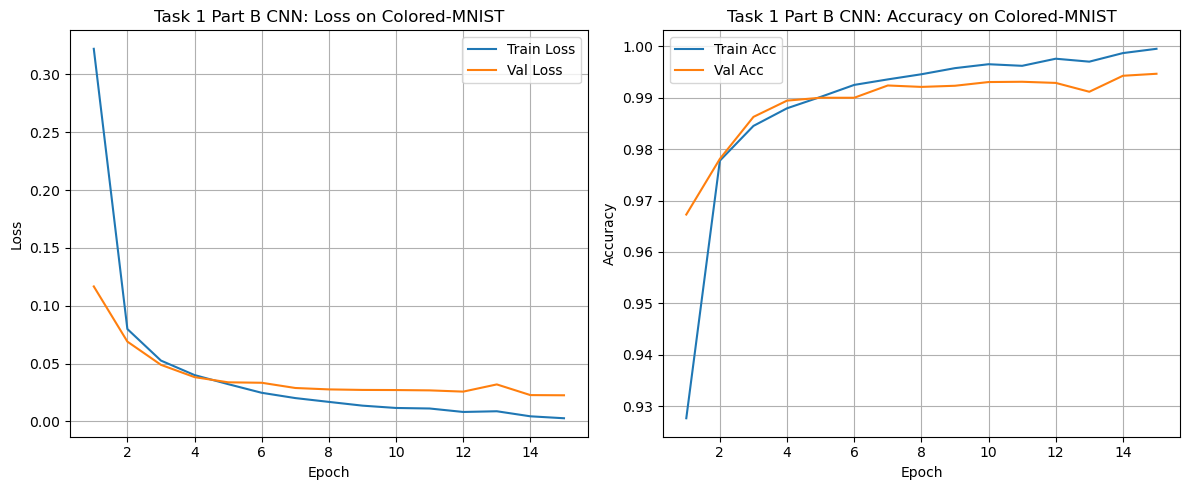

In [17]:
# This block plots Part B training and validation curves.
# Both loss and accuracy trends are shown side by side.
epochs_range_cmnist = range(1, EPOCHS_CMNIST + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_cmnist, cmnist_train_losses, label="Train Loss")
plt.plot(epochs_range_cmnist, cmnist_val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 1 Part B CNN: Loss on Colored-MNIST")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range_cmnist, cmnist_train_accs, label="Train Acc")
plt.plot(epochs_range_cmnist, cmnist_val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Task 1 Part B CNN: Accuracy on Colored-MNIST")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [18]:
# Here we run final evaluation on train, validation, biased test, and unbiased test loaders.
# These numbers directly answer the core requirement of Part B.
cmnist_train_loss, cmnist_train_acc = evaluate(cmnist_model, cmnist_train_loader, loss_function_cmnist)
cmnist_val_loss, cmnist_val_acc = evaluate(cmnist_model, cmnist_val_loader, loss_function_cmnist)
cmnist_test_biased_loss, cmnist_test_biased_acc = evaluate(cmnist_model, cmnist_test_biased_loader, loss_function_cmnist)
cmnist_test_unbiased_loss, cmnist_test_unbiased_acc = evaluate(cmnist_model, cmnist_test_unbiased_loader, loss_function_cmnist)

print(f"C-MNIST Train Loss         : {cmnist_train_loss:.5f}")
print(f"C-MNIST Train Acc          : {cmnist_train_acc:.5f}")
print(f"C-MNIST Val Loss           : {cmnist_val_loss:.5f}")
print(f"C-MNIST Val Acc            : {cmnist_val_acc:.5f}")
print(f"C-MNIST Biased Test Loss   : {cmnist_test_biased_loss:.5f}")
print(f"C-MNIST Biased Test Acc    : {cmnist_test_biased_acc:.5f}")
print(f"C-MNIST Unbiased Test Loss : {cmnist_test_unbiased_loss:.5f}")
print(f"C-MNIST Unbiased Test Acc  : {cmnist_test_unbiased_acc:.5f}")

accuracy_gap = cmnist_test_biased_acc - cmnist_test_unbiased_acc
print(f"Accuracy Gap (Biased - Unbiased): {accuracy_gap:.5f}")

C-MNIST Train Loss         : 0.00209
C-MNIST Train Acc          : 0.99974
C-MNIST Val Loss           : 0.02265
C-MNIST Val Acc            : 0.99467
C-MNIST Biased Test Loss   : 0.01893
C-MNIST Biased Test Acc    : 0.99490
C-MNIST Unbiased Test Loss : 0.28042
C-MNIST Unbiased Test Acc  : 0.93010
Accuracy Gap (Biased - Unbiased): 0.06480
